In [1]:
!pip install transformers accelerate -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/palakjaiswal24/datasetnewsinternetnews/final_training_dataset_refined.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/palakjaiswal24/datasetnewsinternetnews/val_final.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/palakjaiswal24/datasetnewsinternetnews/test_final.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

Train: 105248
Val: 10156
Test: 10157


In [3]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

MAX_LENGTH = 256
STRIDE = 128
MAX_CHUNKS = 5
BATCH_SIZE = 4

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [4]:
class HierarchicalDataset(Dataset):
    def __init__(self, dataframe, tokenizer):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=MAX_LENGTH,
            stride=STRIDE,
            truncation=True,
            padding="max_length",
            return_overflowing_tokens=True,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"]
        attention_mask = encoding["attention_mask"]

        if input_ids.size(0) > MAX_CHUNKS:
            input_ids = input_ids[:MAX_CHUNKS]
            attention_mask = attention_mask[:MAX_CHUNKS]

        pad_chunks = MAX_CHUNKS - input_ids.size(0)

        if pad_chunks > 0:
            pad_input = torch.zeros((pad_chunks, MAX_LENGTH), dtype=torch.long)
            pad_mask = torch.zeros((pad_chunks, MAX_LENGTH), dtype=torch.long)
            input_ids = torch.cat([input_ids, pad_input], dim=0)
            attention_mask = torch.cat([attention_mask, pad_mask], dim=0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": torch.tensor(label, dtype=torch.long)
        }

In [5]:
train_loader = DataLoader(HierarchicalDataset(train_df, tokenizer),
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

val_loader = DataLoader(HierarchicalDataset(val_df, tokenizer),
                        batch_size=BATCH_SIZE,
                        num_workers=2,
                        pin_memory=True)

test_loader = DataLoader(HierarchicalDataset(test_df, tokenizer),
                         batch_size=BATCH_SIZE,
                         num_workers=2,
                         pin_memory=True)

In [6]:
class HierarchicalXLMRBase(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = AutoModel.from_pretrained("xlm-roberta-base")
        hidden_size = 768

        self.doc_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=8,
                dim_feedforward=2048,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=2
        )

        self.attention = nn.Linear(hidden_size, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, input_ids, attention_mask):
        batch_size, num_chunks, seq_len = input_ids.size()

        input_ids = input_ids.view(-1, seq_len)
        attention_mask = attention_mask.view(-1, seq_len)

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        cls_embeddings = cls_embeddings.view(batch_size, num_chunks, -1)

        # 🔥 If short text (only 1 chunk), skip doc transformer
        if num_chunks == 1:
            doc_rep = cls_embeddings.squeeze(1)
        else:
            doc_outputs = self.doc_transformer(cls_embeddings)
            attn_weights = torch.softmax(self.attention(doc_outputs), dim=1)
            doc_rep = torch.sum(attn_weights * doc_outputs, dim=1)

        logits = self.classifier(doc_rep)
        return logits

In [7]:
model = HierarchicalXLMRBase().cuda()

model.load_state_dict(
    torch.load("/kaggle/input/models/palakjaiswal24/modelnewsinternet/pytorch/default/1/final_multilingual_fake_news_model.pt")
)

print("Old model loaded successfully.")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Old model loaded successfully.


In [8]:
LR = 2e-6
EPOCHS = 1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

In [9]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        input_ids = batch["input_ids"].cuda()
        attention_mask = batch["attention_mask"].cuda()
        labels = batch["label"].cuda()

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [10]:
def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()
            labels = batch["label"].cuda()

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [11]:
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nFine-Tuning Epoch {epoch+1}")

    train_loss = train_epoch(model, train_loader)
    val_acc = eval_epoch(model, val_loader)

    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "improved_model_v2.pt")
        print("Improved model saved.")


Fine-Tuning Epoch 1


100%|██████████| 26312/26312 [6:46:56<00:00,  1.08it/s]  


Train Loss: 0.348973881655869
Validation Accuracy: 0.9081331232768807
Improved model saved.


In [12]:
test_acc = eval_epoch(model, test_loader)
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9072560795510486


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def detailed_evaluation(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].cuda(non_blocking=True)
            attention_mask = batch["attention_mask"].cuda(non_blocking=True)
            labels = batch["label"].cuda(non_blocking=True)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"],
        digits=4
    ))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(all_labels, all_preds))

    return all_labels, all_preds


# Run it
labels, preds = detailed_evaluation(model, test_loader)

100%|██████████| 2540/2540 [11:12<00:00,  3.78it/s]


Classification Report:

              precision    recall  f1-score   support

        Real     0.8612    0.9643    0.9098      4929
        Fake     0.9621    0.8535    0.9045      5228

    accuracy                         0.9073     10157
   macro avg     0.9116    0.9089    0.9072     10157
weighted avg     0.9131    0.9073    0.9071     10157


Confusion Matrix:

[[4753  176]
 [ 766 4462]]


In [14]:
def predict_article(text, model, tokenizer):
    model.eval()

    encoding = tokenizer(
        text,
        max_length=MAX_LENGTH,
        stride=STRIDE,
        truncation=True,
        padding="max_length",
        return_overflowing_tokens=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    # Limit chunks
    if input_ids.size(0) > MAX_CHUNKS:
        input_ids = input_ids[:MAX_CHUNKS]
        attention_mask = attention_mask[:MAX_CHUNKS]

    # Pad if needed
    pad_chunks = MAX_CHUNKS - input_ids.size(0)
    if pad_chunks > 0:
        pad_input = torch.zeros((pad_chunks, MAX_LENGTH), dtype=torch.long)
        pad_mask = torch.zeros((pad_chunks, MAX_LENGTH), dtype=torch.long)
        input_ids = torch.cat([input_ids, pad_input], dim=0)
        attention_mask = torch.cat([attention_mask, pad_mask], dim=0)

    input_ids = input_ids.unsqueeze(0).cuda()
    attention_mask = attention_mask.unsqueeze(0).cuda()

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)

    prob_real = probs[0][0].item()
    prob_fake = probs[0][1].item()

    prediction = "Real" if prob_real > prob_fake else "Fake"
    confidence = max(prob_real, prob_fake)

    return {
        "prediction": prediction,
        "confidence": round(confidence, 4),
        "prob_real": round(prob_real, 4),
        "prob_fake": round(prob_fake, 4)
    }

In [21]:
news1 = "ईरान की ज़मीन पर ग्राउंड ऑपरेशन के लिए क्या अपने सैनिक उतारेगा अमेरिका"
print(predict_article(news1, model, tokenizer))

{'prediction': 'Real', 'confidence': 0.9999, 'prob_real': 0.9999, 'prob_fake': 0.0001}


In [20]:
news2 = """
Aliens landed in india.
"""
print(predict_article(news2, model, tokenizer))

{'prediction': 'Fake', 'confidence': 0.9811, 'prob_real': 0.0189, 'prob_fake': 0.9811}


In [18]:
news4 = """
भारतीय रिज़र्व बैंक ने महंगाई को ध्यान में रखते हुए रेपो रेट में कोई बदलाव नहीं किया।
"""
print(predict_article(news4, model, tokenizer))

{'prediction': 'Real', 'confidence': 0.9237, 'prob_real': 0.9237, 'prob_fake': 0.0763}


In [19]:
news5 = """
चौंकाने वाला खुलासा: गुप्त दस्तावेज़ों से पता चला कि एलियन भारत की राजनीति नियंत्रित कर रहे हैं।
"""
print(predict_article(news5, model, tokenizer))

{'prediction': 'Fake', 'confidence': 0.9587, 'prob_real': 0.0413, 'prob_fake': 0.9587}


In [28]:

news6 = "India's top court angry after junior judge cites fake AI-generated orders"
print(predict_article(news6, model, tokenizer))

{'prediction': 'Real', 'confidence': 0.9999, 'prob_real': 0.9999, 'prob_fake': 0.0001}


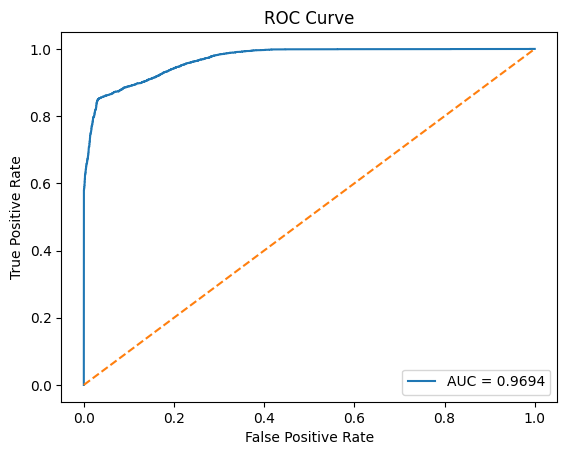

AUC Score: 0.9693628871986802


In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()
            labels = batch["label"].cuda()

            outputs = model(input_ids, attention_mask)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of Fake

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print("AUC Score:", roc_auc)

    return roc_auc


roc_auc = plot_roc(model, test_loader)

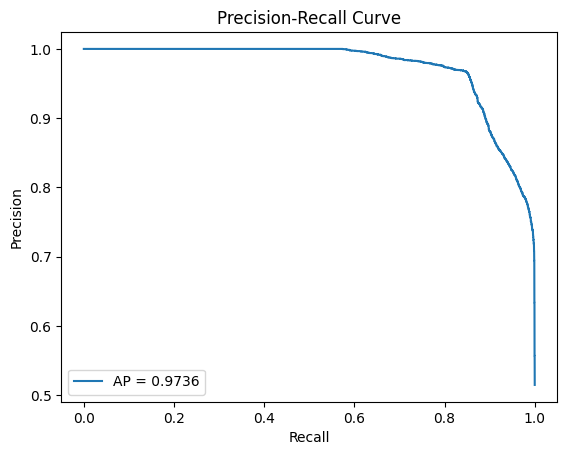

Average Precision Score: 0.9736497112538683


In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()
            labels = batch["label"].cuda()

            outputs = model(input_ids, attention_mask)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    ap_score = average_precision_score(all_labels, all_probs)

    plt.figure()
    plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    print("Average Precision Score:", ap_score)

    return ap_score


ap_score = plot_precision_recall(model, test_loader)

In [32]:
def error_analysis(model, loader, dataframe):
    model.eval()
    misclassified = []

    idx = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()
            labels = batch["label"].cuda()

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append({
                        "text": dataframe.iloc[idx]["text"],
                        "true_label": labels[i].item(),
                        "predicted": preds[i].item()
                    })
                idx += 1

    print("Total Misclassified:", len(misclassified))
    return misclassified


errors = error_analysis(model, test_loader, test_df)

Total Misclassified: 942


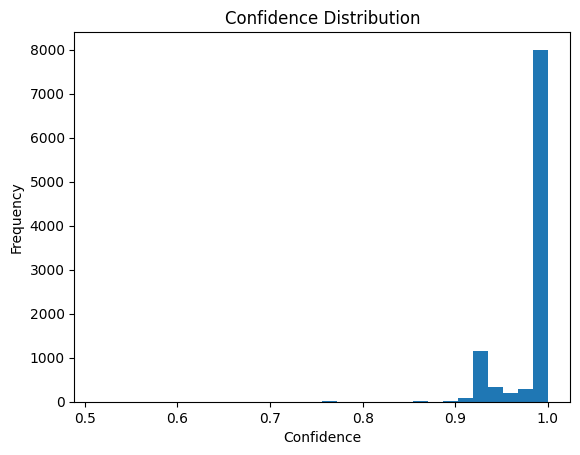

In [33]:
def confidence_distribution(model, loader):
    model.eval()
    confidences = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()

            outputs = model(input_ids, attention_mask)
            probs = torch.softmax(outputs, dim=1)

            max_conf = torch.max(probs, dim=1)[0]
            confidences.extend(max_conf.cpu().numpy())

    plt.hist(confidences, bins=30)
    plt.title("Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.show()

confidence_distribution(model, test_loader)

In [34]:
def language_wise_accuracy(model, loader, dataframe):
    model.eval()
    results = []

    idx = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].cuda()
            attention_mask = batch["attention_mask"].cuda()
            labels = batch["label"].cuda()

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            for i in range(len(labels)):
                results.append({
                    "language": dataframe.iloc[idx]["language"],
                    "correct": int(preds[i] == labels[i])
                })
                idx += 1

    df = pd.DataFrame(results)
    lang_acc = df.groupby("language")["correct"].mean()

    print(lang_acc)
    return lang_acc


language_accuracy = language_wise_accuracy(model, test_loader, test_df)

language
bn    0.863198
en    0.877589
gu    1.000000
hi    0.992657
mr    0.981818
te    0.997972
Name: correct, dtype: float64


In [35]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(labels, preds, average="macro")
weighted_f1 = f1_score(labels, preds, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.9071798896949599
Weighted F1: 0.9071016052723808
